<a href="https://colab.research.google.com/github/shankar-011/GenAI-Internship/blob/master/Day6/Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import zipfile
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

zip_file_path = '/content/archive (21) - Copy - Copy.zip'
extract_root_dir = '/content/extracted_data'

os.makedirs(extract_root_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_root_dir)

data_dir = os.path.join(extract_root_dir, 'brain_tumor_dataset')

IMG_HEIGHT = 128
IMG_WIDTH = 128

images = []
labels = []

class_names = sorted(os.listdir(data_dir))
class_to_label = {name: i for i, name in enumerate(class_names)}

print("Classes:", class_names)

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))

                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(class_to_label[class_name])

            except Exception as e:
                print(f"Error loading {img_path}: {e}")

X = np.array(images)
y = np.array(labels)

print("Dataset Shape:", X.shape)

num_classes = len(class_names)
y = to_categorical(y, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

Classes: ['no', 'yes']
Dataset Shape: (253, 128, 128, 3)
Training Shape: (202, 128, 128, 3)
Testing Shape: (51, 128, 128, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 644ms/step - accuracy: 0.4972 - loss: 0.8262 - val_accuracy: 0.7619 - val_loss: 0.6354
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 638ms/step - accuracy: 0.7459 - loss: 0.5895 - val_accuracy: 0.8095 - val_loss: 0.4469
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 601ms/step - accuracy: 0.7459 - loss: 0.5392 - val_accuracy: 0.6667 - val_loss: 0.5826
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.7735 - loss: 0.4792 - val_accuracy: 0.8095 - val_loss: 0.4177
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 682ms/step - accuracy: 0.7901 - loss: 0.4705 - val_accuracy: 0.8095 - val_loss: 0.5114
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 589ms/step - accuracy: 0.8066 - loss: 0.4416 - val_accuracy: 0.8571 - val_loss: 0.3999
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 694ms/step - accuracy: 0.8287 - loss: 0.4066 - val_accuracy: 0.8571 - val_loss: 0.3577
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 590ms/step - accuracy: 0.8232 - loss: 0.3869 - val_accuracy: 0.8095 - val_loss:

Saving normal brain mri.jpg to normal brain mri.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

Prediction: no


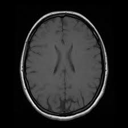

In [8]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
    uploaded_img_path = fn

img = Image.open(uploaded_img_path).convert('RGB')
img = img.resize((IMG_WIDTH, IMG_HEIGHT))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)
predicted_label = class_names[predicted_class]

print(f"\nPrediction: {predicted_label}")

from IPython.display import display
display(img)